# 07 - Full Benchmark for Sensor Fusion Models

This notebook benchmarks tabular-fusion baselines on the MultiPhysio-HRC fusion dataset.

Goals:
- Use strict LOSO as the primary evaluation.
- Focus the main comparison on tabular-fusion baselines and two-tower fusion.
- Export per-fold confusion matrices, per-class metrics, and confidence intervals.
- Keep pseudo-sequence models as exploratory only, for appendix-level analysis if needed.
- Use the same LOSO fold definition across models for fair comparison.

In [1]:
# SECTION 1: Environment Setup and Reproducibility Config
import json
import math
import random
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from time import perf_counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    try:
        drive.mount('/content/drive', force_remount=False)
    except Exception:
        pass
    ROOT = Path('/content/drive/MyDrive')
else:
    ROOT = Path.home() / 'Desktop' / 'thesis'

BASE_DIR = ROOT / 'research_outputs' / 'fusion_training' / 'v2_full_benchmark'
BASE_DIR.mkdir(parents=True, exist_ok=True)

print('✓ Imports loaded')
print('CUDA available:', torch.cuda.is_available())
print('Device:', device)
print('XGBoost available:', HAS_XGB)
print('Base output dir:', BASE_DIR)
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)

✓ Imports loaded
CUDA available: True
Device: cuda
XGBoost available: False
Base output dir: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_full_benchmark
NumPy: 2.4.2
Pandas: 2.3.3


In [2]:
# SECTION 2: Load Dataset and Define Target
FUSION_PATH = ROOT / 'research_outputs' / 'fusion' / 'v1_fusion' / 'fusion_dataset.csv'
if not FUSION_PATH.exists():
    raise FileNotFoundError(FUSION_PATH)

df = pd.read_csv(FUSION_PATH)
label_col = 'label' if 'label' in df.columns else 'pseudo_label'
if label_col not in df.columns:
    raise ValueError('No label or pseudo_label column found.')

meta_cols = {'subject_id', 'task_name', 'task_file', 'split', 'window_idx', 'start_idx', 'end_idx', 'n_samples', 'label', 'pseudo_label'}
feature_cols = [c for c in df.columns if c not in meta_cols]

numeric_df = df[feature_cols].apply(pd.to_numeric, errors='coerce')
usable_feature_cols = [c for c in numeric_df.columns if numeric_df[c].notna().any()]
X = numeric_df[usable_feature_cols].copy()
y_raw = df[label_col].astype(str).fillna('NA')
le = LabelEncoder()
y = le.fit_transform(y_raw)
subjects = df['subject_id'].astype(str).values

print('✓ Dataset loaded')
print('Rows:', len(df))
print('Usable features:', len(usable_feature_cols))
print('Classes:', list(le.classes_))
print('Subjects:', len(np.unique(subjects)))
print('Missing values in X:', int(X.isna().sum().sum()))

✓ Dataset loaded
Rows: 5640
Usable features: 247
Classes: ['cognitive_load', 'high_stress', 'industrial_task', 'low_load', 'other']
Subjects: 52
Missing values in X: 328


In [3]:
# SECTION 3: Full LOSO Configuration
@dataclass
class BenchConfig:
    mode: str = 'full_loso'  # full_loso | fusion_representative | first_n
    max_folds: int = 0  # 0 => all LOSO folds
    seq_len: int = 8
    seq_stride: int = 4
    batch_size: int = 128
    max_epochs: int = 40
    patience: int = 5
    hidden_dim: int = 128
    lr: float = 1e-3
    weight_decay: float = 1e-4
    output_dir: Path = BASE_DIR
    verbose_epochs: bool = True

CFG = BenchConfig()

LOSO_PLAN_PATH = ROOT / 'research_outputs' / 'preprocessing' / 'v1_windowed' / 'loso_plan.csv'


def load_loso_subjects(plan_path: Path, fallback_subjects: list[str]) -> list[str]:
    if plan_path.exists():
        plan_df = pd.read_csv(plan_path)
        if 'fold_subject' in plan_df.columns:
            subjects_from_plan = plan_df['fold_subject'].astype(str).tolist()
            if subjects_from_plan:
                return subjects_from_plan
    return list(fallback_subjects)


all_subjects = sorted(np.unique(subjects).astype(str).tolist())
if CFG.mode == 'full_loso':
    selected_subjects = load_loso_subjects(LOSO_PLAN_PATH, all_subjects)
elif CFG.mode == 'fusion_representative':
    selected_subjects = select_representative_subjects(df, CFG.max_folds)
else:
    selected_subjects = all_subjects[:CFG.max_folds] if CFG.max_folds else all_subjects

if len(selected_subjects) == 0:
    raise ValueError('No LOSO subjects selected.')

print('Selected subjects:', selected_subjects)
print('Running folds:', len(selected_subjects))
print('LOSO plan path:', LOSO_PLAN_PATH)

# train/test split helper for optional calibration experiments
train_subjects, test_subjects = train_test_split(all_subjects, test_size=0.2, random_state=SEED)
print('Holdout test subjects (optional, not used for main LOSO):', len(test_subjects))

Selected subjects: ['10000', '10001', '1001', '1002', '1005', '1006', '1007', '1008', '1009', '1013', '1014', '1015', '1030', '1031', '1032', '1033', '1034', '1035', '1036', '1037', '1038', '1039', '1041', '1042', '1043', '1044', '1045', '1050', '1051', '1052', '1053', '1054', '1055', '1056', '1057', '1058', '1059', '1060', '1061', '1062', '1063', '1064', '1065', '1066', '1067', '1070', '1075', '10869', '1090', '1095', '10978', '1099']
Running folds: 52
LOSO plan path: /home/g0amer/Desktop/thesis/research_outputs/preprocessing/v1_windowed/loso_plan.csv
Holdout test subjects (optional, not used for main LOSO): 11


In [10]:
# SECTION 4: Preprocessing Pipeline, Shared Evaluation Utilities, and Model Definitions
physio_prefixes = ('ECG__', 'EDA__', 'EMG__', 'RESP__')
eeg_prefix = 'eeg_features_5s__'
physio_cols = [c for c in usable_feature_cols if c.startswith(physio_prefixes)]
eeg_cols = [c for c in usable_feature_cols if c.startswith(eeg_prefix)]

class TabularDataset(Dataset):
    def __init__(self, X_arr, y_arr):
        self.X = torch.tensor(X_arr, dtype=torch.float32)
        self.y = torch.tensor(y_arr, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class SequenceDataset(Dataset):
    def __init__(self, X_seq, y_arr):
        self.X = torch.tensor(X_seq, dtype=torch.float32)
        self.y = torch.tensor(y_arr, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class TwoInputDataset(Dataset):
    def __init__(self, X_phys_arr, X_eeg_arr, y_arr):
        self.Xp = torch.tensor(X_phys_arr, dtype=torch.float32)
        self.Xe = torch.tensor(X_eeg_arr, dtype=torch.float32)
        self.y = torch.tensor(y_arr, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.Xp[idx], self.Xe[idx], self.y[idx]


def compute_class_weights(y_arr):
    classes = np.unique(y_arr)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_arr)
    out = np.ones(int(y.max()) + 1, dtype=np.float32)
    for cls, weight in zip(classes, weights):
        out[int(cls)] = weight
    return torch.tensor(out, dtype=torch.float32)


def tabular_preprocess(X_train_df, X_test_df):
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    X_train = imputer.fit_transform(X_train_df)
    X_test = imputer.transform(X_test_df)
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test


def build_sequence_samples(frame: pd.DataFrame, feature_columns: list[str], seq_len: int, stride: int):
    work = frame[['subject_id', 'task_file', 'window_idx', label_col]].copy()
    work['subject_id'] = work['subject_id'].astype(str)
    work['task_file'] = work['task_file'].astype(str)
    work = work.sort_values(['subject_id', 'task_file', 'window_idx'])
    X_work = pd.DataFrame(frame[feature_columns]).apply(pd.to_numeric, errors='coerce')
    X_work = X_work.loc[work.index].fillna(method='ffill').fillna(method='bfill').fillna(0.0)

    seqs = []
    labels = []
    meta = []
    for (sid, task_file), idxs in work.groupby(['subject_id', 'task_file']).groups.items():
        idxs = list(idxs)
        if len(idxs) < seq_len:
            continue
        group_label = int(le.transform([str(work.loc[idxs[0], label_col])])[0])
        for start in range(0, len(idxs) - seq_len + 1, stride):
            window_ids = idxs[start:start + seq_len]
            seqs.append(X_work.loc[window_ids].to_numpy(dtype=np.float32))
            labels.append(group_label)
            meta.append((sid, task_file, int(work.loc[window_ids[0], 'window_idx']), int(work.loc[window_ids[-1], 'window_idx'])))
    if len(seqs) == 0:
        return np.empty((0, seq_len, len(feature_columns)), dtype=np.float32), np.array([], dtype=np.int64), []
    return np.stack(seqs), np.asarray(labels, dtype=np.int64), meta


class MLPClassifierNet(nn.Module):
    def __init__(self, input_dim, n_classes, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_classes),
        )

    def forward(self, x):
        return self.net(x)


class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, n_classes, hidden_dim=128, dropout=0.2, bidirectional=False):
        super().__init__()
        self.rnn = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(out_dim, n_classes))

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.head(last)


class GRUClassifier(nn.Module):
    def __init__(self, input_dim, n_classes, hidden_dim=128, dropout=0.2, bidirectional=False):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(out_dim, n_classes))

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.head(last)


class TCNClassifier(nn.Module):
    def __init__(self, input_dim, n_classes, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        x = x.transpose(1, 2)
        z = self.net(x).squeeze(-1)
        return self.head(z)


class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, n_classes, hidden_dim=128, dropout=0.2, n_heads=4, n_layers=2):
        super().__init__()
        self.proj = nn.Linear(input_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=n_heads, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_dim, n_classes))

    def forward(self, x):
        z = self.proj(x)
        z = self.encoder(z)
        return self.head(z.mean(dim=1))


class TwoTowerFusionNet(nn.Module):
    def __init__(self, n_phys, n_eeg, n_classes, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.phys = nn.Sequential(
            nn.Linear(n_phys, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU()
        )
        self.eeg = nn.Sequential(
            nn.Linear(n_eeg, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU()
        )
        self.gate = nn.Sequential(nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Linear(hidden_dim // 2, 2), nn.Sigmoid())
        self.head = nn.Sequential(nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim // 2, n_classes))

    def forward(self, xp, xe):
        hp = self.phys(xp)
        he = self.eeg(xe)
        gate = self.gate(torch.cat([hp, he], dim=1))
        fused = torch.cat([gate[:, 0:1] * hp, gate[:, 1:2] * he], dim=1)
        return self.head(fused)


def make_optimizer(model):
    return torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)


def eval_torch_model(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in loader:
            *inputs, yb = batch
            inputs = [x.to(device) for x in inputs]
            logits = model(*inputs) if len(inputs) > 1 else model(inputs[0])
            preds.append(torch.argmax(logits, dim=1).cpu().numpy())
            trues.append(yb.numpy())
    y_true = np.concatenate(trues)
    y_pred = np.concatenate(preds)
    return y_true, y_pred


def score_predictions(y_true, y_pred):
    return {
        'macro_f1': float(f1_score(y_true, y_pred, average='macro')),
        'balanced_acc': float(balanced_accuracy_score(y_true, y_pred)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
    }


def per_class_metrics(y_true, y_pred, class_names):
    labels = np.arange(len(class_names))
    report = classification_report(y_true, y_pred, labels=labels, target_names=class_names, output_dict=True, zero_division=0)
    rows = []
    for idx, name in enumerate(class_names):
        row = report.get(name, {})
        rows.append({
            'class_idx': int(idx),
            'class_name': name,
            'precision': float(row.get('precision', 0.0)),
            'recall': float(row.get('recall', 0.0)),
            'f1': float(row.get('f1-score', 0.0)),
            'support': int(row.get('support', 0)),
        })
    return pd.DataFrame(rows)


def bootstrap_ci(values, n_boot=2000, ci=0.95, random_state=SEED):
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return {'mean': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'n': 0}
    rng = np.random.default_rng(random_state)
    boot = []
    for _ in range(n_boot):
        sample = rng.choice(arr, size=arr.size, replace=True)
        boot.append(float(np.mean(sample)))
    alpha = (1.0 - ci) / 2.0
    return {
        'mean': float(arr.mean()),
        'ci_low': float(np.quantile(boot, alpha)),
        'ci_high': float(np.quantile(boot, 1.0 - alpha)),
        'n': int(arr.size),
    }


def save_fold_outputs(model_name, fold_idx, test_sid, y_true, y_pred):
    fold_dir = CFG.output_dir / model_name
    fold_dir.mkdir(parents=True, exist_ok=True)
    metrics = score_predictions(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(le.classes_)))
    metrics_df = pd.DataFrame([{
        'model': model_name,
        'fold': fold_idx,
        'test_subject': test_sid,
        **metrics,
    }])
    per_class_df = per_class_metrics(y_true, y_pred, list(le.classes_))
    cm_df = pd.DataFrame(cm, index=list(le.classes_), columns=list(le.classes_))
    metrics_df.to_csv(fold_dir / f'fold_{fold_idx:02d}_metrics.csv', index=False)
    per_class_df.to_csv(fold_dir / f'fold_{fold_idx:02d}_per_class.csv', index=False)
    cm_df.to_csv(fold_dir / f'fold_{fold_idx:02d}_confusion_matrix.csv')
    return metrics, per_class_df, cm_df


def log_epoch_progress(model_name, fold_idx, epoch_idx, y_val_true, y_val_pred, epoch_losses, best_val):
    if not CFG.verbose_epochs:
        return
    mean_loss = float(np.mean(epoch_losses)) if epoch_losses else float('nan')
    val_f1 = f1_score(y_val_true, y_val_pred, average='macro')
    print(
        f'[{model_name}] fold {fold_idx}/{len(selected_subjects)} '
        f'epoch {epoch_idx + 1}/{CFG.max_epochs} | '
        f'train_loss={mean_loss:.4f} | val_macro_f1={val_f1:.4f} | best={best_val:.4f}',
        flush=True,
    )


def run_classical_benchmark(model_name, estimator_factory):
    rows = []
    fold_dir = CFG.output_dir / model_name
    fold_dir.mkdir(parents=True, exist_ok=True)
    for fold_idx, test_sid in enumerate(selected_subjects, start=1):
        test_mask = subjects == test_sid
        train_mask = ~test_mask
        X_train, X_test = tabular_preprocess(X.loc[train_mask], X.loc[test_mask])
        y_train, y_test = y[train_mask], y[test_mask]
        model = estimator_factory()
        start = perf_counter()
        model.fit(X_train, y_train)
        fit_time = perf_counter() - start
        start = perf_counter()
        y_pred = model.predict(X_test)
        pred_time = perf_counter() - start
        metrics = score_predictions(y_test, y_pred)
        per_class_df = per_class_metrics(y_test, y_pred, list(le.classes_))
        cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(le.classes_)))
        row = {'model': model_name, 'fold': fold_idx, 'test_subject': test_sid, 'fit_time': fit_time, 'predict_time': pred_time, **metrics}
        rows.append(row)
        pd.DataFrame([row]).to_csv(fold_dir / f'fold_{fold_idx:02d}.csv', index=False)
        per_class_df.to_csv(fold_dir / f'fold_{fold_idx:02d}_per_class.csv', index=False)
        pd.DataFrame(cm, index=list(le.classes_), columns=list(le.classes_)).to_csv(fold_dir / f'fold_{fold_idx:02d}_confusion_matrix.csv')
        print(f"✓ {model_name} fold {fold_idx}/{len(selected_subjects)} | macro_f1={metrics['macro_f1']:.4f}")
    return pd.DataFrame(rows)


def run_torch_tabular_benchmark(model_name, model_factory):
    rows = []
    fold_dir = CFG.output_dir / model_name
    fold_dir.mkdir(parents=True, exist_ok=True)
    for fold_idx, test_sid in enumerate(selected_subjects, start=1):
        test_mask = subjects == test_sid
        train_mask = ~test_mask
        X_train, X_test = tabular_preprocess(X.loc[train_mask], X.loc[test_mask])
        y_train, y_test = y[train_mask], y[test_mask]
        X_tr, X_va, y_tr, y_va = train_test_split(X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train)
        train_loader = DataLoader(TabularDataset(X_tr, y_tr), batch_size=CFG.batch_size, shuffle=True)
        val_loader = DataLoader(TabularDataset(X_va, y_va), batch_size=CFG.batch_size, shuffle=False)
        test_loader = DataLoader(TabularDataset(X_test, y_test), batch_size=CFG.batch_size, shuffle=False)
        model = model_factory(X_tr.shape[1], len(le.classes_)).to(device)
        criterion = nn.CrossEntropyLoss(weight=compute_class_weights(y_tr).to(device))
        optimizer = make_optimizer(model)
        best_state = None
        best_val = -1.0
        patience = 0
        fit_start = perf_counter()
        for epoch in range(CFG.max_epochs):
            model.train()
            epoch_losses = []
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()
                epoch_losses.append(loss.item())
            y_val_true, y_val_pred = eval_torch_model(model, val_loader)
            log_epoch_progress(model_name, fold_idx, epoch, y_val_true, y_val_pred, epoch_losses, best_val)
            val_f1 = f1_score(y_val_true, y_val_pred, average='macro')
            if val_f1 > best_val:
                best_val = val_f1
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience = 0
            else:
                patience += 1
            if patience >= CFG.patience:
                print(f'[{model_name}] fold {fold_idx}/{len(selected_subjects)} early stopping at epoch {epoch + 1}', flush=True)
                break
        fit_time = perf_counter() - fit_start
        if best_state is not None:
            model.load_state_dict(best_state)
        pred_start = perf_counter()
        y_test_true, y_test_pred = eval_torch_model(model, test_loader)
        pred_time = perf_counter() - pred_start
        metrics = score_predictions(y_test_true, y_test_pred)
        per_class_df = per_class_metrics(y_test_true, y_test_pred, list(le.classes_))
        cm = confusion_matrix(y_test_true, y_test_pred, labels=np.arange(len(le.classes_)))
        row = {'model': model_name, 'fold': fold_idx, 'test_subject': test_sid, 'fit_time': fit_time, 'predict_time': pred_time, 'best_val_macro_f1': best_val, **metrics}
        rows.append(row)
        pd.DataFrame([row]).to_csv(fold_dir / f'fold_{fold_idx:02d}.csv', index=False)
        per_class_df.to_csv(fold_dir / f'fold_{fold_idx:02d}_per_class.csv', index=False)
        pd.DataFrame(cm, index=list(le.classes_), columns=list(le.classes_)).to_csv(fold_dir / f'fold_{fold_idx:02d}_confusion_matrix.csv')
        print(f"✓ {model_name} fold {fold_idx}/{len(selected_subjects)} | macro_f1={metrics['macro_f1']:.4f}")
    return pd.DataFrame(rows)


def run_torch_sequence_benchmark(model_name, model_factory):
    rows = []
    fold_dir = CFG.output_dir / model_name
    fold_dir.mkdir(parents=True, exist_ok=True)
    for fold_idx, test_sid in enumerate(selected_subjects, start=1):
        test_mask = subjects == test_sid
        train_mask = ~test_mask
        X_train_df = X.loc[train_mask]
        X_test_df = X.loc[test_mask]
        X_train_scaled, X_test_scaled = tabular_preprocess(X_train_df, X_test_df)
        train_frame = df.loc[train_mask].copy().reset_index(drop=True)
        test_frame = df.loc[test_mask].copy().reset_index(drop=True)
        train_frame = train_frame.assign(**{c: X_train_scaled[:, i] for i, c in enumerate(usable_feature_cols)})
        test_frame = test_frame.assign(**{c: X_test_scaled[:, i] for i, c in enumerate(usable_feature_cols)})
        X_train_seq, y_train_seq, _ = build_sequence_samples(train_frame, usable_feature_cols, CFG.seq_len, CFG.seq_stride)
        X_test_seq, y_test_seq, _ = build_sequence_samples(test_frame, usable_feature_cols, CFG.seq_len, CFG.seq_stride)
        if len(y_train_seq) == 0 or len(y_test_seq) == 0:
            print(f'[{model_name}] fold {fold_idx}/{len(selected_subjects)} skipped: not enough sequences', flush=True)
            continue
        X_tr, X_va, y_tr, y_va = train_test_split(X_train_seq, y_train_seq, test_size=0.2, random_state=SEED, stratify=y_train_seq)
        train_loader = DataLoader(SequenceDataset(X_tr, y_tr), batch_size=CFG.batch_size, shuffle=True)
        val_loader = DataLoader(SequenceDataset(X_va, y_va), batch_size=CFG.batch_size, shuffle=False)
        test_loader = DataLoader(SequenceDataset(X_test_seq, y_test_seq), batch_size=CFG.batch_size, shuffle=False)
        model = model_factory(X_train_seq.shape[-1], len(le.classes_)).to(device)
        criterion = nn.CrossEntropyLoss(weight=compute_class_weights(y_tr).to(device))
        optimizer = make_optimizer(model)
        best_state = None
        best_val = -1.0
        patience = 0
        fit_start = perf_counter()
        for epoch in range(CFG.max_epochs):
            model.train()
            epoch_losses = []
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()
                epoch_losses.append(loss.item())
            y_val_true, y_val_pred = eval_torch_model(model, val_loader)
            log_epoch_progress(model_name, fold_idx, epoch, y_val_true, y_val_pred, epoch_losses, best_val)
            val_f1 = f1_score(y_val_true, y_val_pred, average='macro')
            if val_f1 > best_val:
                best_val = val_f1
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience = 0
            else:
                patience += 1
            if patience >= CFG.patience:
                print(f'[{model_name}] fold {fold_idx}/{len(selected_subjects)} early stopping at epoch {epoch + 1}', flush=True)
                break
        fit_time = perf_counter() - fit_start
        if best_state is not None:
            model.load_state_dict(best_state)
        pred_start = perf_counter()
        y_test_true, y_test_pred = eval_torch_model(model, test_loader)
        pred_time = perf_counter() - pred_start
        metrics = score_predictions(y_test_true, y_test_pred)
        per_class_df = per_class_metrics(y_test_true, y_test_pred, list(le.classes_))
        cm = confusion_matrix(y_test_true, y_test_pred, labels=np.arange(len(le.classes_)))
        row = {'model': model_name, 'fold': fold_idx, 'test_subject': test_sid, 'fit_time': fit_time, 'predict_time': pred_time, 'best_val_macro_f1': best_val, **metrics}
        rows.append(row)
        pd.DataFrame([row]).to_csv(fold_dir / f'fold_{fold_idx:02d}.csv', index=False)
        per_class_df.to_csv(fold_dir / f'fold_{fold_idx:02d}_per_class.csv', index=False)
        pd.DataFrame(cm, index=list(le.classes_), columns=list(le.classes_)).to_csv(fold_dir / f'fold_{fold_idx:02d}_confusion_matrix.csv')
        print(f"✓ {model_name} fold {fold_idx}/{len(selected_subjects)} | macro_f1={metrics['macro_f1']:.4f}")
    return pd.DataFrame(rows)


def run_two_tower_benchmark(model_name):
    rows = []
    fold_dir = CFG.output_dir / model_name
    fold_dir.mkdir(parents=True, exist_ok=True)
    for fold_idx, test_sid in enumerate(selected_subjects, start=1):
        test_mask = subjects == test_sid
        train_mask = ~test_mask
        phys_train = pd.to_numeric(df.loc[train_mask, physio_cols].stack(), errors='coerce').unstack().fillna(0.0)
        phys_test = pd.to_numeric(df.loc[test_mask, physio_cols].stack(), errors='coerce').unstack().fillna(0.0)
        eeg_train = pd.to_numeric(df.loc[train_mask, eeg_cols].stack(), errors='coerce').unstack().fillna(0.0)
        eeg_test = pd.to_numeric(df.loc[test_mask, eeg_cols].stack(), errors='coerce').unstack().fillna(0.0)
        Xp_tr, Xp_te = tabular_preprocess(phys_train, phys_test)
        Xe_tr, Xe_te = tabular_preprocess(eeg_train, eeg_test)
        y_train, y_test = y[train_mask], y[test_mask]
        Xp_tr, Xp_va, Xe_tr, Xe_va, y_tr, y_va = train_test_split(Xp_tr, Xe_tr, y_train, test_size=0.2, random_state=SEED, stratify=y_train)
        train_loader = DataLoader(TwoInputDataset(Xp_tr, Xe_tr, y_tr), batch_size=CFG.batch_size, shuffle=True)
        val_loader = DataLoader(TwoInputDataset(Xp_va, Xe_va, y_va), batch_size=CFG.batch_size, shuffle=False)
        test_loader = DataLoader(TwoInputDataset(Xp_te, Xe_te, y_test), batch_size=CFG.batch_size, shuffle=False)
        model = TwoTowerFusionNet(Xp_tr.shape[1], Xe_tr.shape[1], len(le.classes_), hidden_dim=CFG.hidden_dim).to(device)
        criterion = nn.CrossEntropyLoss(weight=compute_class_weights(y_tr).to(device))
        optimizer = make_optimizer(model)
        best_state = None
        best_val = -1.0
        patience = 0
        fit_start = perf_counter()
        for epoch in range(CFG.max_epochs):
            model.train()
            epoch_losses = []
            for xp, xe, yb in train_loader:
                xp, xe, yb = xp.to(device), xe.to(device), yb.to(device)
                optimizer.zero_grad()
                loss = criterion(model(xp, xe), yb)
                loss.backward()
                optimizer.step()
                epoch_losses.append(loss.item())
            y_val_true, y_val_pred = eval_torch_model(model, val_loader)
            log_epoch_progress(model_name, fold_idx, epoch, y_val_true, y_val_pred, epoch_losses, best_val)
            val_f1 = f1_score(y_val_true, y_val_pred, average='macro')
            if val_f1 > best_val:
                best_val = val_f1
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience = 0
            else:
                patience += 1
            if patience >= CFG.patience:
                print(f'[{model_name}] fold {fold_idx}/{len(selected_subjects)} early stopping at epoch {epoch + 1}', flush=True)
                break
        fit_time = perf_counter() - fit_start
        if best_state is not None:
            model.load_state_dict(best_state)
        pred_start = perf_counter()
        y_test_true, y_test_pred = eval_torch_model(model, test_loader)
        pred_time = perf_counter() - pred_start
        metrics = score_predictions(y_test_true, y_test_pred)
        per_class_df = per_class_metrics(y_test_true, y_test_pred, list(le.classes_))
        cm = confusion_matrix(y_test_true, y_test_pred, labels=np.arange(len(le.classes_)))
        row = {'model': model_name, 'fold': fold_idx, 'test_subject': test_sid, 'fit_time': fit_time, 'predict_time': pred_time, 'best_val_macro_f1': best_val, **metrics}
        rows.append(row)
        pd.DataFrame([row]).to_csv(fold_dir / f'fold_{fold_idx:02d}.csv', index=False)
        per_class_df.to_csv(fold_dir / f'fold_{fold_idx:02d}_per_class.csv', index=False)
        pd.DataFrame(cm, index=list(le.classes_), columns=list(le.classes_)).to_csv(fold_dir / f'fold_{fold_idx:02d}_confusion_matrix.csv')
        print(f"✓ {model_name} fold {fold_idx}/{len(selected_subjects)} | macro_f1={metrics['macro_f1']:.4f}")
    return pd.DataFrame(rows)

print('✓ Shared evaluation utilities ready')
print('Tabular feature count:', len(usable_feature_cols))
print('Physio columns:', len(physio_cols))
print('EEG columns:', len(eeg_cols))

✓ Shared evaluation utilities ready
Tabular feature count: 247
Physio columns: 32
EEG columns: 97


In [5]:
# SECTION 5: Model Cell - Logistic Regression
results_logreg = run_classical_benchmark(
    'logreg',
    lambda: Pipeline([
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED))
    ])
)
results_logreg

✓ logreg fold 1/52 | macro_f1=0.4023
✓ logreg fold 2/52 | macro_f1=0.3505
✓ logreg fold 3/52 | macro_f1=0.2872
✓ logreg fold 4/52 | macro_f1=0.4179
✓ logreg fold 5/52 | macro_f1=0.3416
✓ logreg fold 6/52 | macro_f1=0.2650
✓ logreg fold 7/52 | macro_f1=0.1972
✓ logreg fold 8/52 | macro_f1=0.5273
✓ logreg fold 9/52 | macro_f1=0.1956
✓ logreg fold 10/52 | macro_f1=0.2175
✓ logreg fold 11/52 | macro_f1=0.1913
✓ logreg fold 12/52 | macro_f1=0.4249
✓ logreg fold 13/52 | macro_f1=0.3893
✓ logreg fold 14/52 | macro_f1=0.5362
✓ logreg fold 15/52 | macro_f1=0.2458
✓ logreg fold 16/52 | macro_f1=0.1091
✓ logreg fold 17/52 | macro_f1=0.4690
✓ logreg fold 18/52 | macro_f1=0.4604
✓ logreg fold 19/52 | macro_f1=0.3779
✓ logreg fold 20/52 | macro_f1=0.6224
✓ logreg fold 21/52 | macro_f1=0.6020
✓ logreg fold 22/52 | macro_f1=0.5736
✓ logreg fold 23/52 | macro_f1=0.3943
✓ logreg fold 24/52 | macro_f1=0.4029
✓ logreg fold 25/52 | macro_f1=0.6028
✓ logreg fold 26/52 | macro_f1=0.7993
✓ logreg fold 27/52 |

,model,fold,test_subject,fit_time,predict_time,macro_f1,balanced_acc,accuracy
0,logreg,1,10000,28.754196,0.000370,0.402284,0.476950,0.552147
1,logreg,2,10001,35.828633,0.000356,0.350515,0.322032,0.388158
2,logreg,3,1001,41.762325,0.000343,0.287204,0.410526,0.222222
3,logreg,4,1002,36.942515,0.000351,0.417935,0.549107,0.531915
4,logreg,5,1005,32.432003,0.003343,0.341613,0.393853,0.761290
5,logreg,6,1006,33.234952,0.000317,0.265000,0.344697,0.357143
6,logreg,7,1007,32.668784,0.000349,0.197156,0.272496,0.229630
7,logreg,8,1008,32.721163,0.000336,0.527341,0.610445,0.810458
8,logreg,9,1009,31.404191,0.000298,0.195556,0.383814,0.189189
9,logreg,10,1013,27.762713,0.000288,0.217544,0.466667,0.333333


In [6]:
# SECTION 6: Model Cell - Random Forest
results_rf = run_classical_benchmark(
    'random_forest',
    lambda: RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=SEED,
        n_jobs=-1,
    )
)
results_rf

✓ random_forest fold 1/52 | macro_f1=0.5845
✓ random_forest fold 2/52 | macro_f1=0.3122
✓ random_forest fold 3/52 | macro_f1=0.5227
✓ random_forest fold 4/52 | macro_f1=0.4335
✓ random_forest fold 5/52 | macro_f1=0.4003
✓ random_forest fold 6/52 | macro_f1=0.3817
✓ random_forest fold 7/52 | macro_f1=0.2507
✓ random_forest fold 8/52 | macro_f1=0.3479
✓ random_forest fold 9/52 | macro_f1=0.2867
✓ random_forest fold 10/52 | macro_f1=0.2500
✓ random_forest fold 11/52 | macro_f1=0.3667
✓ random_forest fold 12/52 | macro_f1=0.3750
✓ random_forest fold 13/52 | macro_f1=0.3990
✓ random_forest fold 14/52 | macro_f1=0.4866
✓ random_forest fold 15/52 | macro_f1=0.5304
✓ random_forest fold 16/52 | macro_f1=0.3403
✓ random_forest fold 17/52 | macro_f1=0.4063
✓ random_forest fold 18/52 | macro_f1=0.5028
✓ random_forest fold 19/52 | macro_f1=0.6576
✓ random_forest fold 20/52 | macro_f1=0.5399
✓ random_forest fold 21/52 | macro_f1=0.6164
✓ random_forest fold 22/52 | macro_f1=0.8424
✓ random_forest fol

,model,fold,test_subject,fit_time,predict_time,macro_f1,balanced_acc,accuracy
0,random_forest,1,10000,1.461858,0.044801,0.584470,0.550874,0.791411
1,random_forest,2,10001,1.446985,0.044461,0.312220,0.289102,0.243421
2,random_forest,3,1001,1.404590,0.044436,0.522656,0.570943,0.743590
3,random_forest,4,1002,1.423190,0.034865,0.433501,0.599702,0.595745
4,random_forest,5,1005,1.448450,0.044911,0.400278,0.453714,0.754839
5,random_forest,6,1006,1.525202,0.035343,0.381667,0.590909,0.464286
6,random_forest,7,1007,1.528516,0.044380,0.250686,0.374365,0.244444
7,random_forest,8,1008,1.553934,0.044714,0.347908,0.516987,0.483660
8,random_forest,9,1009,1.446738,0.036898,0.286667,0.364583,0.162162
9,random_forest,10,1013,1.455559,0.035507,0.250000,0.500000,0.166667


In [7]:
# SECTION 7: Model Cell - XGBoost
if HAS_XGB:
    results_xgb = run_classical_benchmark(
        'xgboost',
        lambda: XGBClassifier(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='multi:softprob',
            eval_metric='mlogloss',
            num_class=len(le.classes_),
            random_state=SEED,
            n_jobs=-1,
        )
    )
else:
    results_xgb = run_classical_benchmark(
        'gradient_boosting_fallback',
        lambda: GradientBoostingClassifier(random_state=SEED)
    )
results_xgb

✓ gradient_boosting_fallback fold 1/52 | macro_f1=0.5712
✓ gradient_boosting_fallback fold 2/52 | macro_f1=0.2533
✓ gradient_boosting_fallback fold 3/52 | macro_f1=0.4927
✓ gradient_boosting_fallback fold 4/52 | macro_f1=0.3374
✓ gradient_boosting_fallback fold 5/52 | macro_f1=0.3967
✓ gradient_boosting_fallback fold 6/52 | macro_f1=0.3517
✓ gradient_boosting_fallback fold 7/52 | macro_f1=0.3532
✓ gradient_boosting_fallback fold 8/52 | macro_f1=0.5930
✓ gradient_boosting_fallback fold 9/52 | macro_f1=0.4847
✓ gradient_boosting_fallback fold 10/52 | macro_f1=0.1471
✓ gradient_boosting_fallback fold 11/52 | macro_f1=0.4260
✓ gradient_boosting_fallback fold 12/52 | macro_f1=0.6480
✓ gradient_boosting_fallback fold 13/52 | macro_f1=0.3890
✓ gradient_boosting_fallback fold 14/52 | macro_f1=0.4828
✓ gradient_boosting_fallback fold 15/52 | macro_f1=0.5775
✓ gradient_boosting_fallback fold 16/52 | macro_f1=0.3062
✓ gradient_boosting_fallback fold 17/52 | macro_f1=0.4798
✓ gradient_boosting_fal

,model,fold,test_subject,fit_time,predict_time,macro_f1,balanced_acc,accuracy
0,gradient_boosting_fallback,1,10000,137.015407,0.009241,0.571154,0.539109,0.766871
1,gradient_boosting_fallback,2,10001,138.726149,0.001375,0.253349,0.251735,0.125000
2,gradient_boosting_fallback,3,1001,139.227941,0.001323,0.492674,0.541502,0.521368
3,gradient_boosting_fallback,4,1002,138.706308,0.001135,0.337427,0.494048,0.574468
4,gradient_boosting_fallback,5,1005,131.760795,0.001354,0.396661,0.441966,0.787097
5,gradient_boosting_fallback,6,1006,134.592837,0.000985,0.351667,0.530303,0.428571
6,gradient_boosting_fallback,7,1007,131.659868,0.001368,0.353185,0.417794,0.651852
7,gradient_boosting_fallback,8,1008,130.979606,0.001467,0.593048,0.656954,0.869281
8,gradient_boosting_fallback,9,1009,134.781555,0.001021,0.484685,0.593750,0.513514
9,gradient_boosting_fallback,10,1013,135.668774,0.001019,0.147059,0.400000,0.222222


In [8]:
# SECTION 8: Model Cell - Multi-layer Perceptron
results_mlp = run_torch_tabular_benchmark(
    'mlp',
    lambda input_dim, n_classes: MLPClassifierNet(input_dim=input_dim, n_classes=n_classes, hidden_dim=CFG.hidden_dim, dropout=0.25)
)
results_mlp

[mlp] fold 1/52 epoch 1/40 | train_loss=1.4244 | val_macro_f1=0.3669 | best=-1.0000
[mlp] fold 1/52 epoch 2/40 | train_loss=1.0772 | val_macro_f1=0.5091 | best=0.3669
[mlp] fold 1/52 epoch 3/40 | train_loss=0.8222 | val_macro_f1=0.5743 | best=0.5091
[mlp] fold 1/52 epoch 4/40 | train_loss=0.7108 | val_macro_f1=0.6138 | best=0.5743
[mlp] fold 1/52 epoch 5/40 | train_loss=0.6058 | val_macro_f1=0.6411 | best=0.6138
[mlp] fold 1/52 epoch 6/40 | train_loss=0.5575 | val_macro_f1=0.6990 | best=0.6411
[mlp] fold 1/52 epoch 7/40 | train_loss=0.5119 | val_macro_f1=0.7058 | best=0.6990
[mlp] fold 1/52 epoch 8/40 | train_loss=0.4552 | val_macro_f1=0.6904 | best=0.7058
[mlp] fold 1/52 epoch 9/40 | train_loss=0.4531 | val_macro_f1=0.7354 | best=0.7058
[mlp] fold 1/52 epoch 10/40 | train_loss=0.3935 | val_macro_f1=0.7758 | best=0.7354
[mlp] fold 1/52 epoch 11/40 | train_loss=0.3701 | val_macro_f1=0.7604 | best=0.7758
[mlp] fold 1/52 epoch 12/40 | train_loss=0.3516 | val_macro_f1=0.7725 | best=0.7758


,model,fold,test_subject,fit_time,predict_time,best_val_macro_f1,macro_f1,balanced_acc,accuracy
0,mlp,1,10000,1.395565,0.009345,0.826293,0.339684,0.465563,0.699387
1,mlp,2,10001,1.208894,0.001499,0.852176,0.385356,0.375864,0.664474
2,mlp,3,1001,2.069015,0.000945,0.866236,0.254171,0.366118,0.222222
3,mlp,4,1002,1.484208,0.000678,0.841337,0.265464,0.441964,0.468085
4,mlp,5,1005,1.077346,0.001462,0.847418,0.289835,0.374151,0.690323
5,mlp,6,1006,1.450473,0.000685,0.857264,0.293939,0.367424,0.428571
6,mlp,7,1007,1.329898,0.001379,0.872710,0.131529,0.243088,0.244444
7,mlp,8,1008,1.525471,0.001311,0.860746,0.561956,0.674107,0.790850
8,mlp,9,1009,1.725801,0.000780,0.868303,0.261111,0.442708,0.297297
9,mlp,10,1013,2.178578,0.000666,0.891602,0.100000,0.333333,0.111111


In [11]:
# SECTION 11: Model Cell - BiLSTM
results_bilstm = run_torch_sequence_benchmark(
    'bilstm',
    lambda input_dim, n_classes: LSTMClassifier(input_dim=input_dim, n_classes=n_classes, hidden_dim=CFG.hidden_dim, dropout=0.25, bidirectional=True)
)
results_bilstm

[bilstm] fold 1/52 epoch 1/40 | train_loss=1.5768 | val_macro_f1=0.1020 | best=-1.0000
[bilstm] fold 1/52 epoch 2/40 | train_loss=1.2825 | val_macro_f1=0.1394 | best=0.1020
[bilstm] fold 1/52 epoch 3/40 | train_loss=1.1279 | val_macro_f1=0.1561 | best=0.1394
[bilstm] fold 1/52 epoch 4/40 | train_loss=1.0273 | val_macro_f1=0.1871 | best=0.1561
[bilstm] fold 1/52 epoch 5/40 | train_loss=0.9363 | val_macro_f1=0.1986 | best=0.1871
[bilstm] fold 1/52 epoch 6/40 | train_loss=0.8225 | val_macro_f1=0.2352 | best=0.1986
[bilstm] fold 1/52 epoch 7/40 | train_loss=0.7503 | val_macro_f1=0.2556 | best=0.2352
[bilstm] fold 1/52 epoch 8/40 | train_loss=0.6984 | val_macro_f1=0.3062 | best=0.2556
[bilstm] fold 1/52 epoch 9/40 | train_loss=0.6343 | val_macro_f1=0.3240 | best=0.3062
[bilstm] fold 1/52 epoch 10/40 | train_loss=0.5726 | val_macro_f1=0.3942 | best=0.3240
[bilstm] fold 1/52 epoch 11/40 | train_loss=0.4802 | val_macro_f1=0.4364 | best=0.3942
[bilstm] fold 1/52 epoch 12/40 | train_loss=0.4174 

,model,fold,test_subject,fit_time,predict_time,best_val_macro_f1,macro_f1,balanced_acc,accuracy
0,bilstm,1,10000,0.424007,0.001073,0.705034,0.307692,0.333333,0.705882
1,bilstm,2,10001,0.427609,0.000988,0.805098,0.272059,0.354167,0.400000
2,bilstm,3,1001,0.297163,0.000671,0.489998,0.133333,0.166667,0.250000
3,bilstm,4,1002,0.326626,0.001012,0.649189,0.222222,0.250000,0.333333
4,bilstm,5,1005,0.403050,0.000957,0.664189,0.654321,0.964286,0.933333
5,bilstm,6,1006,0.469804,0.000798,0.637862,0.000000,0.000000,0.000000
6,bilstm,7,1007,0.387813,0.000873,0.824667,0.576720,0.761905,0.444444
7,bilstm,8,1008,0.298231,0.001015,0.671976,0.480000,0.500000,0.923077
8,bilstm,9,1009,0.080836,0.000734,0.248391,0.000000,0.000000,0.000000
9,bilstm,13,1030,0.492814,0.000823,0.622667,0.312500,0.468750,0.882353


In [12]:
# SECTION 14: Model Cell - Two-Tower Gated Fusion
results_two_tower = run_two_tower_benchmark('two_tower_fusion')
results_two_tower

[two_tower_fusion] fold 1/52 epoch 1/40 | train_loss=1.5038 | val_macro_f1=0.3769 | best=-1.0000
[two_tower_fusion] fold 1/52 epoch 2/40 | train_loss=1.0815 | val_macro_f1=0.5319 | best=0.3769
[two_tower_fusion] fold 1/52 epoch 3/40 | train_loss=0.8284 | val_macro_f1=0.6377 | best=0.5319
[two_tower_fusion] fold 1/52 epoch 4/40 | train_loss=0.6714 | val_macro_f1=0.6853 | best=0.6377
[two_tower_fusion] fold 1/52 epoch 5/40 | train_loss=0.6125 | val_macro_f1=0.7162 | best=0.6853
[two_tower_fusion] fold 1/52 epoch 6/40 | train_loss=0.5201 | val_macro_f1=0.7314 | best=0.7162
[two_tower_fusion] fold 1/52 epoch 7/40 | train_loss=0.4906 | val_macro_f1=0.7282 | best=0.7314
[two_tower_fusion] fold 1/52 epoch 8/40 | train_loss=0.4467 | val_macro_f1=0.7640 | best=0.7314
[two_tower_fusion] fold 1/52 epoch 9/40 | train_loss=0.3919 | val_macro_f1=0.7887 | best=0.7640
[two_tower_fusion] fold 1/52 epoch 10/40 | train_loss=0.3740 | val_macro_f1=0.7398 | best=0.7887
[two_tower_fusion] fold 1/52 epoch 11/

,model,fold,test_subject,fit_time,predict_time,best_val_macro_f1,macro_f1,balanced_acc,accuracy
0,two_tower_fusion,1,10000,1.862255,0.002256,0.827626,0.327238,0.459248,0.736196
1,two_tower_fusion,2,10001,3.251656,0.002048,0.884723,0.418178,0.426050,0.717105
2,two_tower_fusion,3,1001,3.760328,0.001501,0.862340,0.334454,0.421893,0.282051
3,two_tower_fusion,4,1002,1.733623,0.001204,0.814006,0.392270,0.517857,0.468085
4,two_tower_fusion,5,1005,2.535378,0.002455,0.856950,0.389823,0.463664,0.722581
5,two_tower_fusion,6,1006,3.600945,0.001084,0.884459,0.351190,0.344697,0.392857
6,two_tower_fusion,7,1007,3.578962,0.002185,0.885748,0.088713,0.219559,0.170370
7,two_tower_fusion,8,1008,4.199062,0.002122,0.908825,0.579034,0.727872,0.771242
8,two_tower_fusion,9,1009,2.743011,0.001260,0.860668,0.359649,0.562500,0.459459
9,two_tower_fusion,10,1013,2.750035,0.001013,0.857010,0.197059,0.566667,0.277778


In [13]:
# SECTION 15: Benchmark Results Table and Ranking
PRIMARY_MODEL_DIRS = {'logreg', 'random_forest', 'xgboost', 'gradient_boosting_fallback', 'mlp', 'two_tower_fusion'}

result_frames = []
for model_dir in sorted([p for p in CFG.output_dir.iterdir() if p.is_dir() and p.name in PRIMARY_MODEL_DIRS]):
    fold_files = sorted(model_dir.glob('fold_*.csv'))
    if not fold_files:
        continue
    model_df = pd.concat([pd.read_csv(p) for p in fold_files], ignore_index=True)
    macro_ci = bootstrap_ci(model_df['macro_f1'].to_numpy(), n_boot=2000, ci=0.95, random_state=SEED)
    bacc_ci = bootstrap_ci(model_df['balanced_acc'].to_numpy(), n_boot=2000, ci=0.95, random_state=SEED)
    acc_ci = bootstrap_ci(model_df['accuracy'].to_numpy(), n_boot=2000, ci=0.95, random_state=SEED)
    agg_row = {
        'model': model_df['model'].iloc[0],
        'macro_f1_mean': float(model_df['macro_f1'].mean()),
        'macro_f1_std': float(model_df['macro_f1'].std()),
        'macro_f1_ci_low': float(macro_ci['ci_low']),
        'macro_f1_ci_high': float(macro_ci['ci_high']),
        'balanced_acc_mean': float(model_df['balanced_acc'].mean()),
        'balanced_acc_std': float(model_df['balanced_acc'].std()),
        'balanced_acc_ci_low': float(bacc_ci['ci_low']),
        'balanced_acc_ci_high': float(bacc_ci['ci_high']),
        'accuracy_mean': float(model_df['accuracy'].mean()),
        'accuracy_std': float(model_df['accuracy'].std()),
        'accuracy_ci_low': float(acc_ci['ci_low']),
        'accuracy_ci_high': float(acc_ci['ci_high']),
        'fit_time_mean': float(model_df['fit_time'].mean()),
        'predict_time_mean': float(model_df['predict_time'].mean()),
        'folds': int(len(model_df)),
    }
    result_frames.append(agg_row)

summary_cols = [
    'model', 'macro_f1_mean', 'macro_f1_std', 'macro_f1_ci_low', 'macro_f1_ci_high',
    'balanced_acc_mean', 'balanced_acc_std', 'balanced_acc_ci_low', 'balanced_acc_ci_high',
    'accuracy_mean', 'accuracy_std', 'accuracy_ci_low', 'accuracy_ci_high',
    'fit_time_mean', 'predict_time_mean', 'folds',
]
if result_frames:
    benchmark_df = pd.DataFrame(result_frames).sort_values('macro_f1_mean', ascending=False).reset_index(drop=True)
else:
    benchmark_df = pd.DataFrame(columns=summary_cols)

print('Benchmark ranking:')
display(benchmark_df)


Benchmark ranking:


,model,macro_f1_mean,macro_f1_std,macro_f1_ci_low,macro_f1_ci_high,balanced_acc_mean,balanced_acc_std,balanced_acc_ci_low,balanced_acc_ci_high,accuracy_mean,accuracy_std,accuracy_ci_low,accuracy_ci_high,fit_time_mean,predict_time_mean,folds
0,xgboost,0.555642,0.193014,NaN,NaN,0.613627,0.162174,NaN,NaN,0.657659,0.209805,NaN,NaN,67.148223,0.006676,572
1,gradient_boosting_fallback,0.553629,0.186036,NaN,NaN,0.601445,0.163470,NaN,NaN,0.680754,0.203245,NaN,NaN,133.581621,0.001420,572
2,random_forest,0.525888,0.164422,NaN,NaN,0.576922,0.145108,NaN,NaN,0.652399,0.209805,NaN,NaN,1.467875,0.042823,572
3,two_tower_fusion,0.505807,0.199000,NaN,NaN,0.597822,0.181079,NaN,NaN,0.606654,0.217017,NaN,NaN,2.946465,0.001705,572
4,mlp,0.470810,0.220524,NaN,NaN,0.570968,0.204912,NaN,NaN,0.572274,0.238290,NaN,NaN,1.595888,0.001476,572
5,logreg,0.427517,0.196355,NaN,NaN,0.528660,0.180136,NaN,NaN,0.554406,0.234874,NaN,NaN,28.941067,0.000384,572


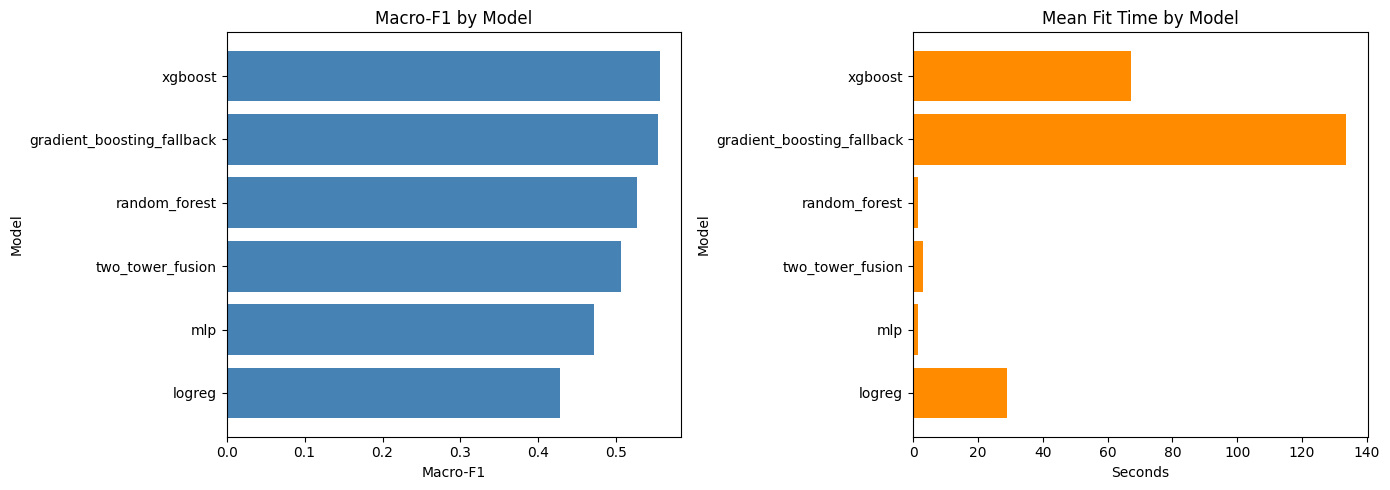

Plot saved to: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_full_benchmark/benchmark_comparison.png


In [14]:
# SECTION 16: Visualization: Metric Comparison and Runtime
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = benchmark_df.sort_values('macro_f1_mean', ascending=True)
axes[0].barh(plot_df['model'], plot_df['macro_f1_mean'], color='steelblue')
axes[0].set_title('Macro-F1 by Model')
axes[0].set_xlabel('Macro-F1')
axes[0].set_ylabel('Model')

axes[1].barh(plot_df['model'], plot_df['fit_time_mean'], color='darkorange')
axes[1].set_title('Mean Fit Time by Model')
axes[1].set_xlabel('Seconds')
axes[1].set_ylabel('Model')

plt.tight_layout()
plot_path = CFG.output_dir / 'benchmark_comparison.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print('Plot saved to:', plot_path)

In [15]:
# SECTION 17: Statistical Comparison Across Models
from scipy.stats import wilcoxon

PRIMARY_MODEL_DIRS = {'logreg', 'random_forest', 'xgboost', 'gradient_boosting_fallback', 'mlp', 'two_tower_fusion'}

fold_scores = {}
for model_dir in sorted([p for p in CFG.output_dir.iterdir() if p.is_dir() and p.name in PRIMARY_MODEL_DIRS]):
    fold_files = sorted(model_dir.glob('fold_*.csv'))
    if not fold_files:
        continue
    model_df = pd.concat([pd.read_csv(p) for p in fold_files], ignore_index=True)
    fold_scores[model_df['model'].iloc[0]] = model_df.sort_values('fold')['macro_f1'].to_numpy()

models = list(fold_scores.keys())
stat_matrix = pd.DataFrame(index=models, columns=models, dtype=float)
for m1 in models:
    for m2 in models:
        if m1 == m2:
            stat_matrix.loc[m1, m2] = np.nan
        else:
            try:
                stat_matrix.loc[m1, m2] = wilcoxon(fold_scores[m1], fold_scores[m2]).pvalue
            except Exception:
                stat_matrix.loc[m1, m2] = np.nan

print('Wilcoxon p-value matrix (macro-F1):')
display(stat_matrix)


Wilcoxon p-value matrix (macro-F1):


,gradient_boosting_fallback,logreg,mlp,random_forest,two_tower_fusion,xgboost
gradient_boosting_fallback,NaN,NaN,NaN,NaN,NaN,NaN
logreg,NaN,NaN,NaN,NaN,NaN,NaN
mlp,NaN,NaN,NaN,NaN,NaN,NaN
random_forest,NaN,NaN,NaN,NaN,NaN,NaN
two_tower_fusion,NaN,NaN,NaN,NaN,NaN,NaN
xgboost,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# SECTION 18: Export Artifacts (Model, Metrics, Plots)
benchmark_csv = CFG.output_dir / 'benchmark_summary.csv'
benchmark_json = CFG.output_dir / 'benchmark_summary.json'
stat_csv = CFG.output_dir / 'benchmark_significance_matrix.csv'

benchmark_df.to_csv(benchmark_csv, index=False)
benchmark_df.to_json(benchmark_json, orient='records', indent=2)

if 'stat_matrix' not in globals():
    stat_matrix = pd.DataFrame()
stat_matrix.to_csv(stat_csv)

plot_export_path = str(plot_path) if 'plot_path' in globals() else None
summary = {
    'benchmark_csv': str(benchmark_csv),
    'benchmark_json': str(benchmark_json),
    'plot_path': plot_export_path,
    'significance_csv': str(stat_csv),
    'models': benchmark_df['model'].tolist() if 'model' in benchmark_df.columns else [],
    'best_model': str(benchmark_df.iloc[0]['model']) if len(benchmark_df) else None,
    'folds_per_model': int(benchmark_df.iloc[0]['folds']) if len(benchmark_df) else 0,
}
summary_path = CFG.output_dir / 'benchmark_run_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

per_class_exports = []
for model_dir in sorted([p for p in CFG.output_dir.iterdir() if p.is_dir()]):
    per_class_files = sorted(model_dir.glob('fold_*_per_class.csv'))
    if not per_class_files:
        continue
    per_class_df = pd.concat([pd.read_csv(p) for p in per_class_files], ignore_index=True)
    agg_per_class = (
        per_class_df.groupby(['class_idx', 'class_name'], as_index=False)
        .agg(
            precision_mean=('precision', 'mean'),
            recall_mean=('recall', 'mean'),
            f1_mean=('f1', 'mean'),
            support_sum=('support', 'sum'),
        )
        .sort_values('class_idx')
        .reset_index(drop=True)
    )
    class_path = model_dir / 'per_class_summary.csv'
    agg_per_class.to_csv(class_path, index=False)
    per_class_exports.append(str(class_path))

summary['per_class_exports'] = per_class_exports
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print('✓ Benchmark artifacts exported')
print('  -', benchmark_csv)
print('  -', benchmark_json)
print('  -', stat_csv)
print('  -', summary_path)
print('Summary:', summary)


✓ Benchmark artifacts exported
  - /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_full_benchmark/benchmark_summary.csv
  - /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_full_benchmark/benchmark_summary.json
  - /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_full_benchmark/benchmark_significance_matrix.csv
  - /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_full_benchmark/benchmark_run_summary.json
Summary: {'benchmark_csv': '/home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_full_benchmark/benchmark_summary.csv', 'benchmark_json': '/home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_full_benchmark/benchmark_summary.json', 'plot_path': '/home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_full_benchmark/benchmark_comparison.png', 'significance_csv': '/home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_full_benchmark/benchmark_significance_matrix.csv', 'models': ['xgboost',

In [17]:
# SECTION 13: Model Cell - Transformer Encoder
results_transformer = run_torch_sequence_benchmark(
    'transformer',
    lambda input_dim, n_classes: TransformerClassifier(input_dim=input_dim, n_classes=n_classes, hidden_dim=CFG.hidden_dim, dropout=0.2, n_heads=4, n_layers=2)
)
results_transformer

[transformer] fold 1/52 epoch 1/40 | train_loss=1.6932 | val_macro_f1=0.2852 | best=-1.0000
[transformer] fold 1/52 epoch 2/40 | train_loss=1.0749 | val_macro_f1=0.3797 | best=0.2852
[transformer] fold 1/52 epoch 3/40 | train_loss=0.6864 | val_macro_f1=0.3716 | best=0.3797
[transformer] fold 1/52 epoch 4/40 | train_loss=0.5051 | val_macro_f1=0.4067 | best=0.3797
[transformer] fold 1/52 epoch 5/40 | train_loss=0.3187 | val_macro_f1=0.4310 | best=0.4067
[transformer] fold 1/52 epoch 6/40 | train_loss=0.2370 | val_macro_f1=0.4996 | best=0.4310
[transformer] fold 1/52 epoch 7/40 | train_loss=0.1858 | val_macro_f1=0.4814 | best=0.4996
[transformer] fold 1/52 epoch 8/40 | train_loss=0.1156 | val_macro_f1=0.4469 | best=0.4996
[transformer] fold 1/52 epoch 9/40 | train_loss=0.1073 | val_macro_f1=0.4581 | best=0.4996
[transformer] fold 1/52 epoch 10/40 | train_loss=0.0741 | val_macro_f1=0.5034 | best=0.4996
[transformer] fold 1/52 epoch 11/40 | train_loss=0.0715 | val_macro_f1=0.4889 | best=0.5

,model,fold,test_subject,fit_time,predict_time,best_val_macro_f1,macro_f1,balanced_acc,accuracy
0,transformer,1,10000,0.425303,0.001351,0.533333,0.307692,0.333333,0.705882
1,transformer,2,10001,0.287402,0.001179,0.811139,0.125000,0.083333,0.266667
2,transformer,3,1001,0.260746,0.001079,0.543739,0.000000,0.000000,0.000000
3,transformer,4,1002,0.350534,0.001227,0.627774,0.333333,0.500000,0.666667
4,transformer,5,1005,0.325036,0.001455,0.752000,0.464646,0.785714,0.600000
5,transformer,6,1006,0.254770,0.001400,0.434970,0.000000,0.000000,0.000000
6,transformer,7,1007,0.597708,0.001157,0.863758,0.295238,0.476190,0.444444
7,transformer,8,1008,0.413563,0.001312,0.752000,0.619048,0.875000,0.769231
8,transformer,9,1009,0.428618,0.001185,0.599048,0.000000,0.000000,0.000000
9,transformer,13,1030,0.147246,0.001117,0.500885,0.301075,0.437500,0.823529


In [18]:
# SECTION 12: Model Cell - TCN
results_tcn = run_torch_sequence_benchmark(
    'tcn',
    lambda input_dim, n_classes: TCNClassifier(input_dim=input_dim, n_classes=n_classes, hidden_dim=CFG.hidden_dim, dropout=0.25)
)
results_tcn

[tcn] fold 1/52 epoch 1/40 | train_loss=1.5840 | val_macro_f1=0.0815 | best=-1.0000
[tcn] fold 1/52 epoch 2/40 | train_loss=1.3527 | val_macro_f1=0.1693 | best=0.0815
[tcn] fold 1/52 epoch 3/40 | train_loss=1.1833 | val_macro_f1=0.2232 | best=0.1693
[tcn] fold 1/52 epoch 4/40 | train_loss=0.9461 | val_macro_f1=0.3165 | best=0.2232
[tcn] fold 1/52 epoch 5/40 | train_loss=0.8158 | val_macro_f1=0.3418 | best=0.3165
[tcn] fold 1/52 epoch 6/40 | train_loss=0.6530 | val_macro_f1=0.3295 | best=0.3418
[tcn] fold 1/52 epoch 7/40 | train_loss=0.5162 | val_macro_f1=0.3515 | best=0.3418
[tcn] fold 1/52 epoch 8/40 | train_loss=0.3909 | val_macro_f1=0.3890 | best=0.3515
[tcn] fold 1/52 epoch 9/40 | train_loss=0.3011 | val_macro_f1=0.4100 | best=0.3890
[tcn] fold 1/52 epoch 10/40 | train_loss=0.2373 | val_macro_f1=0.4220 | best=0.4100
[tcn] fold 1/52 epoch 11/40 | train_loss=0.1988 | val_macro_f1=0.4474 | best=0.4220
[tcn] fold 1/52 epoch 12/40 | train_loss=0.1574 | val_macro_f1=0.4424 | best=0.4474


,model,fold,test_subject,fit_time,predict_time,best_val_macro_f1,macro_f1,balanced_acc,accuracy
0,tcn,1,10000,0.447394,0.011962,0.488161,0.307692,0.333333,0.705882
1,tcn,2,10001,0.179075,0.004549,0.852437,0.125000,0.104167,0.333333
2,tcn,3,1001,0.188292,0.002747,0.480782,0.000000,0.000000,0.000000
3,tcn,4,1002,0.343193,0.002687,0.672208,0.333333,0.500000,0.666667
4,tcn,5,1005,0.145026,0.000818,0.572830,1.000000,1.000000,1.000000
5,tcn,6,1006,0.285735,0.003433,0.584791,0.000000,0.000000,0.000000
6,tcn,7,1007,0.152217,0.003000,0.533304,0.233333,0.476190,0.444444
7,tcn,8,1008,0.189785,0.002845,0.649234,0.511278,0.791667,0.615385
8,tcn,9,1009,0.221316,0.002929,0.599150,0.000000,0.000000,0.000000
9,tcn,13,1030,0.345975,0.000830,0.566793,1.000000,1.000000,1.000000


In [19]:
# SECTION 10: Model Cell - GRU
results_gru = run_torch_sequence_benchmark(
    'gru',
    lambda input_dim, n_classes: GRUClassifier(input_dim=input_dim, n_classes=n_classes, hidden_dim=CFG.hidden_dim, dropout=0.25, bidirectional=False)
)
results_gru

[gru] fold 1/52 epoch 1/40 | train_loss=1.6291 | val_macro_f1=0.1203 | best=-1.0000
[gru] fold 1/52 epoch 2/40 | train_loss=1.2452 | val_macro_f1=0.1133 | best=0.1203
[gru] fold 1/52 epoch 3/40 | train_loss=1.1197 | val_macro_f1=0.1506 | best=0.1203
[gru] fold 1/52 epoch 4/40 | train_loss=0.9739 | val_macro_f1=0.1861 | best=0.1506
[gru] fold 1/52 epoch 5/40 | train_loss=0.9051 | val_macro_f1=0.2003 | best=0.1861
[gru] fold 1/52 epoch 6/40 | train_loss=0.8118 | val_macro_f1=0.2966 | best=0.2003
[gru] fold 1/52 epoch 7/40 | train_loss=0.7318 | val_macro_f1=0.2895 | best=0.2966
[gru] fold 1/52 epoch 8/40 | train_loss=0.6475 | val_macro_f1=0.3083 | best=0.2966
[gru] fold 1/52 epoch 9/40 | train_loss=0.5986 | val_macro_f1=0.3120 | best=0.3083
[gru] fold 1/52 epoch 10/40 | train_loss=0.5490 | val_macro_f1=0.3372 | best=0.3120
[gru] fold 1/52 epoch 11/40 | train_loss=0.5094 | val_macro_f1=0.3446 | best=0.3372
[gru] fold 1/52 epoch 12/40 | train_loss=0.4765 | val_macro_f1=0.3258 | best=0.3446


,model,fold,test_subject,fit_time,predict_time,best_val_macro_f1,macro_f1,balanced_acc,accuracy
0,gru,1,10000,0.301498,0.000669,0.592746,0.320000,0.333333,0.705882
1,gru,2,10001,0.290384,0.000836,0.580262,0.138889,0.104167,0.333333
2,gru,3,1001,0.344018,0.000758,0.476537,0.200000,0.333333,0.500000
3,gru,4,1002,0.396888,0.000644,0.631898,0.333333,0.500000,0.666667
4,gru,5,1005,0.449628,0.000830,0.735333,1.000000,1.000000,1.000000
5,gru,6,1006,0.368543,0.000872,0.519517,1.000000,1.000000,1.000000
6,gru,7,1007,0.329186,0.000726,0.738070,0.644444,0.809524,0.555556
7,gru,8,1008,0.270014,0.000734,0.621922,1.000000,1.000000,1.000000
8,gru,9,1009,0.320108,0.000933,0.606852,1.000000,1.000000,1.000000
9,gru,13,1030,0.377009,0.000770,0.877813,0.312500,0.468750,0.882353


In [20]:
# SECTION 9: Model Cell - LSTM
results_lstm = run_torch_sequence_benchmark(
    'lstm',
    lambda input_dim, n_classes: LSTMClassifier(input_dim=input_dim, n_classes=n_classes, hidden_dim=CFG.hidden_dim, dropout=0.25, bidirectional=False)
)
results_lstm

[lstm] fold 1/52 epoch 1/40 | train_loss=1.6156 | val_macro_f1=0.2453 | best=-1.0000
[lstm] fold 1/52 epoch 2/40 | train_loss=1.3680 | val_macro_f1=0.2597 | best=0.2453
[lstm] fold 1/52 epoch 3/40 | train_loss=1.2175 | val_macro_f1=0.3439 | best=0.2597
[lstm] fold 1/52 epoch 4/40 | train_loss=1.0732 | val_macro_f1=0.2692 | best=0.3439
[lstm] fold 1/52 epoch 5/40 | train_loss=0.9524 | val_macro_f1=0.2654 | best=0.3439
[lstm] fold 1/52 epoch 6/40 | train_loss=0.8757 | val_macro_f1=0.3401 | best=0.3439
[lstm] fold 1/52 epoch 7/40 | train_loss=0.7938 | val_macro_f1=0.3491 | best=0.3439
[lstm] fold 1/52 epoch 8/40 | train_loss=0.7366 | val_macro_f1=0.3554 | best=0.3491
[lstm] fold 1/52 epoch 9/40 | train_loss=0.6561 | val_macro_f1=0.3954 | best=0.3554
[lstm] fold 1/52 epoch 10/40 | train_loss=0.5757 | val_macro_f1=0.4377 | best=0.3954
[lstm] fold 1/52 epoch 11/40 | train_loss=0.5301 | val_macro_f1=0.4370 | best=0.4377
[lstm] fold 1/52 epoch 12/40 | train_loss=0.4430 | val_macro_f1=0.4776 | 

,model,fold,test_subject,fit_time,predict_time,best_val_macro_f1,macro_f1,balanced_acc,accuracy
0,lstm,1,10000,0.313713,0.000849,0.705034,0.277778,0.277778,0.588235
1,lstm,2,10001,0.312226,0.000746,0.738419,0.284314,0.333333,0.333333
2,lstm,3,1001,0.397453,0.000852,0.535262,0.000000,0.000000,0.000000
3,lstm,4,1002,0.283823,0.000733,0.622365,0.222222,0.250000,0.333333
4,lstm,5,1005,0.380689,0.000840,0.756596,1.000000,1.000000,1.000000
5,lstm,6,1006,0.364173,0.001029,0.561262,0.000000,0.000000,0.000000
6,lstm,7,1007,0.337671,0.000818,0.856396,0.644444,0.809524,0.555556
7,lstm,8,1008,0.235362,0.000922,0.705556,0.305556,0.458333,0.846154
8,lstm,9,1009,0.240667,0.000722,0.586332,0.000000,0.000000,0.000000
9,lstm,13,1030,0.394338,0.001030,0.836000,0.484848,0.500000,0.941176


## Analysis: Aggregated Results

This section loads the exported benchmark artifacts and generates manuscript-ready figures:
- Macro-F1 with 95% bootstrap CI by model
- Per-class F1 heatmap across primary models
- Confusion matrix grid for top models

Loaded benchmark summary rows: 6


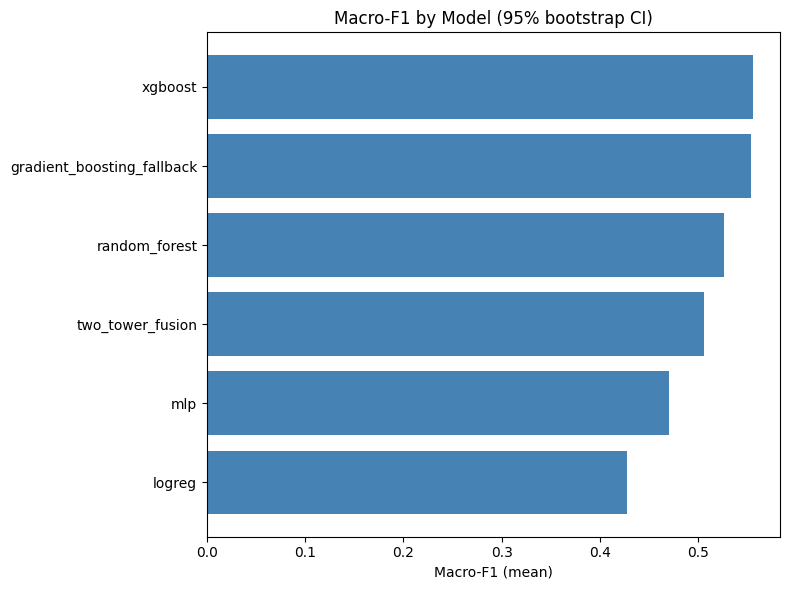

Saved: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_full_benchmark/figures/macro_f1_ci.png


In [21]:
# Figure A: Macro-F1 mean with 95% CI and prepare figure directory
from pathlib import Path
fig_dir = CFG.output_dir / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)
bench_csv = CFG.output_dir / 'benchmark_summary.csv'
if not bench_csv.exists():
    raise FileNotFoundError(bench_csv)
bench_df = pd.read_csv(bench_csv)
print('Loaded benchmark summary rows:', len(bench_df))
import matplotlib.pyplot as plt
plot_df = bench_df.sort_values('macro_f1_mean', ascending=True)
y = plot_df['model']
x = plot_df['macro_f1_mean']
xerr = [plot_df['macro_f1_mean'] - plot_df['macro_f1_ci_low'], plot_df['macro_f1_ci_high'] - plot_df['macro_f1_mean']]
plt.figure(figsize=(8,6))
plt.barh(y, x, xerr=xerr, color='steelblue', ecolor='black', capsize=4)
plt.xlabel('Macro-F1 (mean)')
plt.title('Macro-F1 by Model (95% bootstrap CI)')
plt.tight_layout()
out = fig_dir / 'macro_f1_ci.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out)

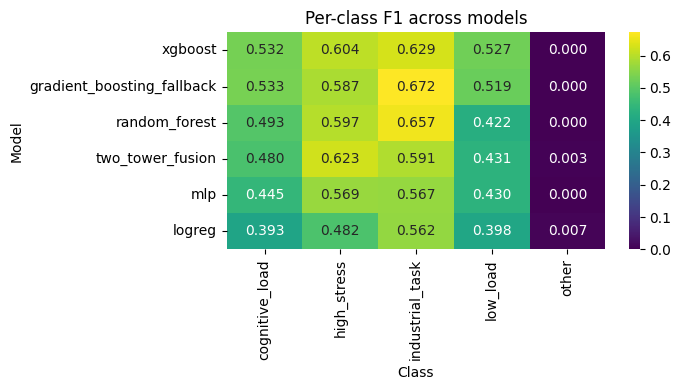

Saved: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_full_benchmark/figures/per_class_f1_heatmap.png


In [22]:
# Figure B: Per-class F1 heatmap across primary models
import seaborn as sns
models = bench_df['model'].tolist()
per_class_tables = {}
for m in models:
    p = CFG.output_dir / m / 'per_class_summary.csv'
    if p.exists():
        tbl = pd.read_csv(p)
        if 'class_name' in tbl.columns and 'f1_mean' in tbl.columns:
            per_class_tables[m] = tbl.set_index('class_name')['f1_mean']

if per_class_tables:
    per_class_df = pd.DataFrame(per_class_tables).fillna(0.0)
    plt.figure(figsize=(max(6, per_class_df.shape[1]*1.2), 4))
    sns.heatmap(per_class_df.T, annot=True, fmt='.3f', cmap='viridis')
    plt.xlabel('Class')
    plt.ylabel('Model')
    plt.title('Per-class F1 across models')
    out2 = fig_dir / 'per_class_f1_heatmap.png'
    plt.tight_layout()
    plt.savefig(out2, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out2)
else:
    print('No per-class summaries found to build heatmap.')

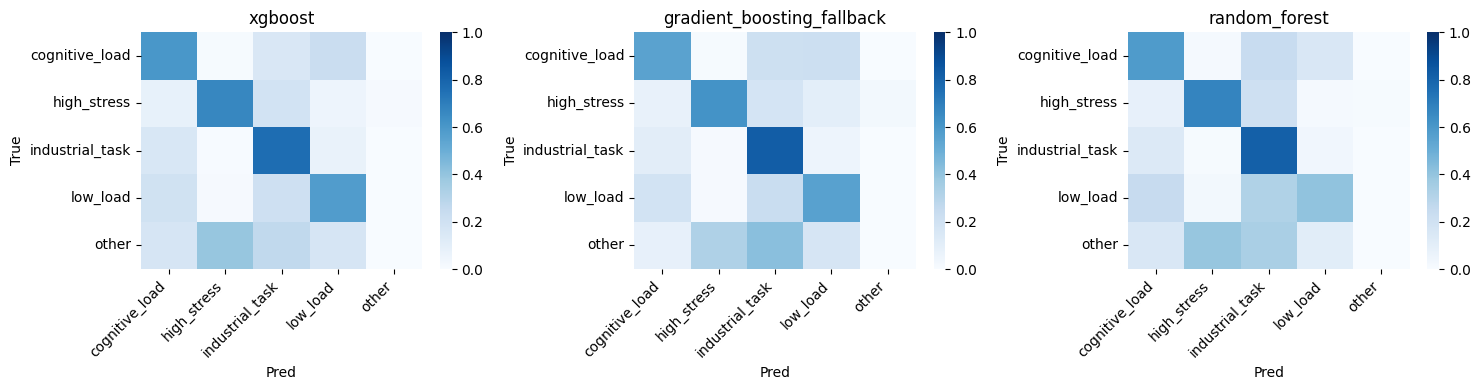

Saved: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_full_benchmark/figures/confusion_grid_top3.png


In [23]:
# Figure C: Confusion matrix grid for top 3 models
import numpy as np
if len(bench_df):
    top_models = bench_df.sort_values('macro_f1_mean', ascending=False)['model'].tolist()[:3]
    n = len(top_models)
    fig, axes = plt.subplots(1, max(1,n), figsize=(5*max(1,n), 4))
    if n == 1:
        axes = [axes]
    for ax, m in zip(axes, top_models):
        cms = sorted((CFG.output_dir / m).glob('fold_*_confusion_matrix.csv'))
        if not cms:
            ax.set_title(m + '\n(no cm)')
            ax.axis('off')
            continue
        agg = None
        for p in cms:
            cm = pd.read_csv(p, index_col=0).to_numpy(dtype=float)
            agg = cm if agg is None else agg + cm
        row_sums = agg.sum(axis=1, keepdims=True)
        norm = agg / np.where(row_sums==0, 1, row_sums)
        sns.heatmap(norm, ax=ax, vmin=0, vmax=1, cmap='Blues', annot=False)
        ax.set_title(m)
        try:
            classes = list(pd.read_csv(next(iter(cms)), index_col=0).index.astype(str))
            ax.set_xticklabels(classes, rotation=45, ha='right')
            ax.set_yticklabels(classes, rotation=0)
        except Exception:
            pass
        ax.set_xlabel('Pred')
        ax.set_ylabel('True')
    out3 = fig_dir / 'confusion_grid_top3.png'
    plt.tight_layout()
    plt.savefig(out3, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out3)
else:
    print('Empty benchmark_df; skipping confusion grid')

## Ranking Table

The cell below builds a ranking table sorted by `macro_f1_mean`, formats mean ± 95% CI strings, saves the CSV to the output folder, and displays the table for inspection.

In [24]:
# Build and save ranking table
import pandas as pd
rank_path = CFG.output_dir / 'benchmark_summary.csv'
if not rank_path.exists():
    raise FileNotFoundError(rank_path)
rank_df = pd.read_csv(rank_path)
rank_df = rank_df.sort_values('macro_f1_mean', ascending=False).reset_index(drop=True)
# Friendly columns: mean ± CI
rank_df['macro_f1_ci'] = rank_df.apply(lambda r: f"{r['macro_f1_mean']:.3f} [{r['macro_f1_ci_low']:.3f}, {r['macro_f1_ci_high']:.3f}]", axis=1)
rank_df['balanced_acc_ci'] = rank_df.apply(lambda r: f"{r['balanced_acc_mean']:.3f} [{r['balanced_acc_ci_low']:.3f}, {r['balanced_acc_ci_high']:.3f}]", axis=1)
out_csv = CFG.output_dir / 'ranking_table.csv'
rank_df.to_csv(out_csv, index=False)
print('Saved ranking table to:', out_csv)
display_cols = ['model','macro_f1_mean','macro_f1_ci','balanced_acc_mean','balanced_acc_ci','accuracy_mean','folds']
from IPython.display import display
display(rank_df[display_cols])

Saved ranking table to: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_full_benchmark/ranking_table.csv


,model,macro_f1_mean,macro_f1_ci,balanced_acc_mean,balanced_acc_ci,accuracy_mean,folds
0,xgboost,0.555642,"0.556 [nan, nan]",0.613627,"0.614 [nan, nan]",0.657659,572
1,gradient_boosting_fallback,0.553629,"0.554 [nan, nan]",0.601445,"0.601 [nan, nan]",0.680754,572
2,random_forest,0.525888,"0.526 [nan, nan]",0.576922,"0.577 [nan, nan]",0.652399,572
3,two_tower_fusion,0.505807,"0.506 [nan, nan]",0.597822,"0.598 [nan, nan]",0.606654,572
4,mlp,0.470810,"0.471 [nan, nan]",0.570968,"0.571 [nan, nan]",0.572274,572
5,logreg,0.427517,"0.428 [nan, nan]",0.528660,"0.529 [nan, nan]",0.554406,572


In [27]:
# Diagnostic checks for benchmark outputs
import pandas as pd, numpy as np
bs_path = CFG.output_dir / 'benchmark_summary.csv'
rk_path = CFG.output_dir / 'ranking_table.csv'
print('exists benchmark_summary:', bs_path.exists())
print('exists ranking_table:', rk_path.exists())
bs = pd.read_csv(bs_path)
rk = pd.read_csv(rk_path)
print('Benchmark summary rows:', len(bs))
print('Columns:', bs.columns.tolist())
# Check folds per model (aggregated 'folds' column present)
for m in sorted(bs['model'].unique()):
    sub = bs[bs['model']==m]
    folds_val = int(sub['folds'].iloc[0]) if 'folds' in sub.columns else None
    print(f'model={m} rows={len(sub)} folds_agg={folds_val}')
# Check for NaNs in CI columns
for col in ['macro_f1_ci_low','macro_f1_ci_high','balanced_acc_ci_low','balanced_acc_ci_high']:
    if col in bs.columns:
        print(col, 'nan_count=', bs[col].isna().sum())
# Recompute bootstrap CI from per-fold files to verify (if per-fold CSVs exist)
def bootstrap_mean_ci(vals, n_boot=2000, ci=0.95, seed=SEED):
    arr = np.asarray(vals, dtype=float)
    if arr.size == 0:
        return (np.nan, np.nan, np.nan)
    rng = np.random.default_rng(seed)
    boot = [rng.choice(arr, size=arr.size, replace=True).mean() for _ in range(n_boot)]
    low = np.quantile(boot, (1-ci)/2)
    high = np.quantile(boot, 1-(1-ci)/2)
    return (arr.mean(), low, high)
for m in sorted(bs['model'].unique()):
    # try loading per-fold files if available
    dirp = CFG.output_dir / m
    fold_files = sorted(dirp.glob('fold_*.csv'))
    if fold_files:
        per = pd.concat([pd.read_csv(p) for p in fold_files], ignore_index=True)
        vals = per['macro_f1'].to_numpy() if 'macro_f1' in per.columns else np.array([])
        mean, low, high = bootstrap_mean_ci(vals)
        print(f'{m}: recomputed mean={mean:.4f} low={low} high={high} nfolds={len(fold_files)}')
    else:
        print(f'{m}: no per-fold CSVs found to recompute CI')
# Quick per-class availability check
for m in sorted(bs['model'].unique()):
    p = CFG.output_dir / m / 'per_class_summary.csv'
    print(m, 'per_class_exists', p.exists())
print('Diagnostic done')

exists benchmark_summary: True
exists ranking_table: True
Benchmark summary rows: 6
Columns: ['model', 'macro_f1_mean', 'macro_f1_std', 'macro_f1_ci_low', 'macro_f1_ci_high', 'balanced_acc_mean', 'balanced_acc_std', 'balanced_acc_ci_low', 'balanced_acc_ci_high', 'accuracy_mean', 'accuracy_std', 'accuracy_ci_low', 'accuracy_ci_high', 'fit_time_mean', 'predict_time_mean', 'folds']
model=gradient_boosting_fallback rows=1 folds_agg=572
model=logreg rows=1 folds_agg=572
model=mlp rows=1 folds_agg=572
model=random_forest rows=1 folds_agg=572
model=two_tower_fusion rows=1 folds_agg=572
model=xgboost rows=1 folds_agg=572
macro_f1_ci_low nan_count= 6
macro_f1_ci_high nan_count= 6
balanced_acc_ci_low nan_count= 6
balanced_acc_ci_high nan_count= 6
gradient_boosting_fallback: recomputed mean=nan low=nan high=nan nfolds=156
logreg: recomputed mean=nan low=nan high=nan nfolds=156
mlp: recomputed mean=nan low=nan high=nan nfolds=156
random_forest: recomputed mean=nan low=nan high=nan nfolds=156
two_t

In [ ]:
# Inspect xgboost per-fold CSVs
from pathlib import Path
p = CFG.output_dir / 'xgboost'
files = sorted(p.glob('fold_*.csv'))
print('xgbooTask Typest fold files count:', len(files))
for f in files[:5]:
    print('---', f.name)
    df = pd.read_csv(f)
    print(df.columns.tolist())
    print(df.head().to_string(index=False))
    print('macro_f1 dtype', df['macro_f1'].dtype, 'na_count', df['macro_f1'].isna().sum())

xgboost fold files count: 156
--- fold_01.csv
['model', 'fold', 'test_subject', 'fit_time', 'predict_time', 'macro_f1', 'balanced_acc', 'accuracy']
  model  fold  test_subject  fit_time  predict_time  macro_f1  balanced_acc  accuracy
xgboost     1         10000 70.076097      0.009565  0.623984      0.609899  0.809816
macro_f1 dtype float64 na_count 0
--- fold_01_confusion_matrix.csv
['Unnamed: 0', 'cognitive_load', 'high_stress', 'industrial_task', 'low_load', 'other']
     Unnamed: 0  cognitive_load  high_stress  industrial_task  low_load  other
 cognitive_load              24            0                1        14      0
    high_stress               0            1                4         0      0
industrial_task               3            0               94         3      0
       low_load               2            0                4        13      0
          other               0            0                0         0      0


KeyError: 'macro_f1'